In [1]:
!pip install -q pandas numpy
!pip install -q networkx
!pip install -q scikit-learn
!pip install -q catboost
!pip install -q shap
!pip install -q matplotlib seaborn plotly
!pip install -q joblib tqdm
!pip install -q openpyxl
!pip install -q python-dateutil
!pip install -q colorama

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.6 which is incompatible.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.4.6 which is incompatible.


In [2]:
import json
import warnings
from pathlib import Path
from datetime import datetime

import joblib
import networkx as nx
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

In [3]:
SEED = 42

np.random.seed(SEED)

DATA_DIR = Path("Dataset/problem_10/")
APPLICATION_FILE = DATA_DIR / "applications.json"
SBOM_FILE = DATA_DIR / "sbom_dependencies.csv"
TRANSITIVE_FILE = DATA_DIR / "transitive_dependencies.json"
VULNERABILITY_FILE = DATA_DIR / "vulnerability_db.json"
LICENSE_FILE = DATA_DIR / "license_rules.json"
LABEL_FILE = DATA_DIR / "dependency_labels.csv"
OUTPUT_DIR = Path("./output")
MODEL_DIR = Path("./models")

OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

In [6]:
print("=" * 70)
print("Loading Dataset")
print("=" * 70)

applications = pd.read_json(APPLICATION_FILE)

sbom = pd.read_csv(SBOM_FILE)

transitive = pd.read_json(TRANSITIVE_FILE)

vulnerabilities = pd.read_json(VULNERABILITY_FILE)

licenses = pd.read_json(LICENSE_FILE)

labels = pd.read_csv(LABEL_FILE, encoding="latin-1")

print(f"Applications     : {applications.shape}")
print(f"SBOM             : {sbom.shape}")
print(f"Transitive       : {transitive.shape}")
print(f"Vulnerabilities  : {vulnerabilities.shape}")
print(f"Licenses         : {licenses.shape}")
print(f"Labels           : {labels.shape}")

Loading Dataset
Applications     : (10, 8)
SBOM             : (500, 9)
Transitive       : (372, 5)
Vulnerabilities  : (200, 10)
Licenses         : (15, 6)
Labels           : (500, 8)


In [7]:
datasets = {
    "Applications": applications,
    "SBOM": sbom,
    "Transitive": transitive,
    "Vulnerabilities": vulnerabilities,
    "Licenses": licenses,
    "Labels": labels,
}

for name, df in datasets.items():

    print("=" * 80)

    print(name)

    print("=" * 80)

    display(df.head())

    print(df.info())

    print(df.isnull().sum())

    print()

Applications


,app_id,name,language,criticality,license_model,business_owner,department,deployment
0,APP-001,CustomerPortal,Java,HIGH,proprietary,Sarah Chen,Engineering,cloud
1,APP-002,PaymentService,Java,CRITICAL,proprietary,Mike Torres,Finance,cloud
2,APP-003,InternalAPI,Python,MEDIUM,proprietary,Priya Patel,Engineering,on-prem
3,APP-004,HRPortal,Python,HIGH,proprietary,James Wilson,HR,cloud
4,APP-005,AnalyticsDashboard,JavaScript,MEDIUM,proprietary,Lisa Wang,Data,cloud


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   app_id          10 non-null     object
 1   name            10 non-null     object
 2   language        10 non-null     object
 3   criticality     10 non-null     object
 4   license_model   10 non-null     object
 5   business_owner  10 non-null     object
 6   department      10 non-null     object
 7   deployment      10 non-null     object
dtypes: object(8)
memory usage: 772.0+ bytes
None
app_id            0
name              0
language          0
criticality       0
license_model     0
business_owner    0
department        0
deployment        0
dtype: int64

SBOM


,dep_id,application_id,application_name,library,version,license,dependency_type,last_updated,transitive_deps
0,DEP-0001,APP-001,CustomerPortal,micrometer-core,3.0.10,Apache-2.0,direct,2025-01-30,tomcat-embed-core:2.4.0
1,DEP-0002,APP-001,CustomerPortal,sqlalchemy,5.13.5,ISC,direct,2022-03-18,NaN
2,DEP-0003,APP-001,CustomerPortal,netty-all,2.7.4,Unlicense,direct,2025-05-01,assertj-core:2.1.1
3,DEP-0004,APP-001,CustomerPortal,json-iterator,2.3.2,BSD-2-Clause,direct,2024-12-30,disruptor:3.1.0
4,DEP-0005,APP-001,CustomerPortal,log4j-api,5.1.3,Apache-2.0,direct,2025-07-11,eslint:3.4.1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   dep_id            500 non-null    object
 1   application_id    500 non-null    object
 2   application_name  500 non-null    object
 3   library           500 non-null    object
 4   version           500 non-null    object
 5   license           500 non-null    object
 6   dependency_type   500 non-null    object
 7   last_updated      500 non-null    object
 8   transitive_deps   240 non-null    object
dtypes: object(9)
memory usage: 35.3+ KB
None
dep_id                0
application_id        0
application_name      0
library               0
version               0
license               0
dependency_type       0
last_updated          0
transitive_deps     260
dtype: int64

Transitive


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cve_id             200 non-null    object 
 1   library            200 non-null    object 
 2   affected_versions  200 non-null    object 
 3   fixed_version      144 non-null    object 
 4   cvss_score         200 non-null    float64
 5   severity           200 non-null    object 
 6   exploitability     200 non-null    object 
 7   description        200 non-null    object 
 8   patch_available    200 non-null    bool   
 9   published_date     200 non-null    object 
dtypes: bool(1), float64(1), object(8)
memory usage: 14.4+ KB
None
cve_id                0
library               0
affected_versions     0
fixed_version        56
cvss_score            0
severity              0
exploitability        0
description           0
patch_available       0
published_date        0
dtype: int64

,license,spdx,risk_level,compatible_with_proprietary,viral,notes
0,MIT,MIT,LOW,True,False,Permissive; no restrictions on use
1,Apache-2.0,Apache-2.0,LOW,True,False,Permissive; patent grant included
2,BSD-2-Clause,BSD-2-Clause,LOW,True,False,Permissive; minimal restrictions
3,BSD-3-Clause,BSD-3-Clause,LOW,True,False,Permissive; no endorsement clause
4,ISC,ISC,LOW,True,False,Permissive; simplified BSD


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   license                      15 non-null     object
 1   spdx                         15 non-null     object
 2   risk_level                   15 non-null     object
 3   compatible_with_proprietary  15 non-null     bool  
 4   viral                        15 non-null     bool  
 5   notes                        15 non-null     object
dtypes: bool(2), object(4)
memory usage: 642.0+ bytes
None
license                        0
spdx                           0
risk_level                     0
compatible_with_proprietary    0
viral                          0
notes                          0
dtype: int64

Labels


,dep_id,application_id,library,version,is_risky,risk_type,severity,explanation
0,DEP-0001,APP-001,micrometer-core,3.0.10,True,VULNERABLE_DEPENDENCY,MEDIUM,Library micrometer-core:3.0.10 has CVE-2026-10...
1,DEP-0002,APP-001,sqlalchemy,5.13.5,True,VULNERABLE_DEPENDENCY,LOW,Library sqlalchemy:5.13.5 has CVE-2024-1183 (C...
2,DEP-0003,APP-001,netty-all,2.7.4,True,VULNERABLE_DEPENDENCY,MEDIUM,Library netty-all:2.7.4 has CVE-2024-1163 (CVS...
3,DEP-0004,APP-001,json-iterator,2.3.2,True,VULNERABLE_DEPENDENCY,MEDIUM,Library json-iterator:2.3.2 has CVE-2022-1083 ...
4,DEP-0005,APP-001,log4j-api,5.1.3,True,VULNERABLE_DEPENDENCY,MEDIUM,Library log4j-api:5.1.3 has CVE-2022-1041 (CVS...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   dep_id          500 non-null    object
 1   application_id  500 non-null    object
 2   library         500 non-null    object
 3   version         500 non-null    object
 4   is_risky        500 non-null    bool  
 5   risk_type       500 non-null    object
 6   severity        500 non-null    object
 7   explanation     500 non-null    object
dtypes: bool(1), object(7)
memory usage: 28.0+ KB
None
dep_id            0
application_id    0
library           0
version           0
is_risky          0
risk_type         0
severity          0
explanation       0
dtype: int64



In [ ]:
def validate_dataframe(df, name):
    print("=" * 70)
    print(name)
    print("=" * 70)
    print("Rows :", len(df))
    print("Columns :", len(df.columns))
    
    df_hashable = df.copy()
    for col in df_hashable.columns:
        # Convert lists/sets to tuples, and dicts to frozen strings so they can be hashed
        if df_hashable[col].apply(lambda x: isinstance(x, (list, dict, set))).any():
            df_hashable[col] = df_hashable[col].apply(lambda x: tuple(x) if isinstance(x, (list, set)) else str(x))
    
    print("Duplicates :", df_hashable.duplicated().sum())
    
    print("Missing Values")
    print(df.isnull().sum())
    print()

for name, df in datasets.items():
    validate_dataframe(df, name)

Applications
Rows : 10
Columns : 8
Duplicates : 0
Missing Values
app_id            0
name              0
language          0
criticality       0
license_model     0
business_owner    0
department        0
deployment        0
dtype: int64

SBOM
Rows : 500
Columns : 9
Duplicates : 0
Missing Values
dep_id                0
application_id        0
application_name      0
library               0
version               0
license               0
dependency_type       0
last_updated          0
transitive_deps     260
dtype: int64

Transitive
Rows : 372
Columns : 5
Duplicates : 0
Missing Values
parent_library    0
parent_version    0
child_library     0
child_version     0
application_id    0
dtype: int64

Vulnerabilities
Rows : 200
Columns : 10
Duplicates : 0
Missing Values
cve_id                0
library               0
affected_versions     0
fixed_version        56
cvss_score            0
severity              0
exploitability        0
description           0
patch_available       0
published

In [10]:
# ==========================================================
# Data Normalization
# ==========================================================

def normalize_string(value):
    if pd.isna(value):
        return None
    return str(value).strip().lower()


def normalize_license(value):
    if pd.isna(value):
        return "UNKNOWN"
    return str(value).strip().upper()


def normalize_version(value):
    if pd.isna(value):
        return "0.0.0"

    return str(value).strip()

for df in [
    sbom,
    vulnerabilities,
    transitive
]:
    for column in df.columns:
        if "library" in column.lower():
            df[column] = df[column].apply(normalize_string)

if "license" in sbom.columns:
    sbom["license"] = sbom["license"].apply(normalize_license)

print("Normalization Completed")

Normalization Completed


In [11]:
# ==========================================================
# Convert Dates
# ==========================================================

sbom["last_updated"] = pd.to_datetime(
    sbom["last_updated"],
    errors="coerce"
)

today = pd.Timestamp.today()

sbom["years_since_update"] = (
    (today - sbom["last_updated"]).dt.days
    /365.25
)

sbom["years_since_update"] = sbom["years_since_update"].fillna(100)

In [12]:
# ==========================================================
# Maintenance Features
# ==========================================================

sbom["is_unmaintained"] = (
    sbom["years_since_update"] >= 2
).astype(int)

sbom["maintenance_score"] = np.where(
    sbom["years_since_update"] >= 5,
    100,
    np.where(
        sbom["years_since_update"] >= 2,
        60,
        10
    )
)

display(
    sbom[
        [
            "library",
            "years_since_update",
            "maintenance_score",
            "is_unmaintained"
        ]
    ].head()
)

,library,years_since_update,maintenance_score,is_unmaintained
0,micrometer-core,1.445585,10,0
1,sqlalchemy,4.317591,60,1
2,netty-all,1.196441,10,0
3,json-iterator,1.530459,10,0
4,log4j-api,1.002053,10,0


In [13]:
# ==========================================================
# Merge License Rules
# ==========================================================

licenses["license"] = licenses["license"].str.upper()

sbom = sbom.merge(
    licenses,
    how="left",
    on="license"
)

sbom["risk_level"] = sbom["risk_level"].fillna("HIGH")
sbom["viral"] = sbom["viral"].fillna(False)
sbom["compatible_with_proprietary"] = (
    sbom["compatible_with_proprietary"]
    .fillna(False)
)

In [14]:
# ==========================================================
# Vulnerability Merge
# ==========================================================

vulnerabilities["library"] = (
    vulnerabilities["library"]
    .str.lower()
)

sbom = sbom.merge(
    vulnerabilities,
    how="left",
    on="library"
)

sbom["has_cve"] = (
    sbom["cve_id"]
    .notna()
).astype(int)

sbom["cvss_score"] = (
    sbom["cvss_score"]
    .fillna(0)
)

sbom["patch_available"] = (
    sbom["patch_available"]
    .fillna(False)
).astype(int)

In [15]:
# ==========================================================
# Merge Applications
# ==========================================================

applications = applications.rename(
    columns={
        "app_id":"application_id"
    }
)

sbom = sbom.merge(
    applications,
    how="left",
    on="application_id"
)

criticality_score = {
    "LOW":1,
    "MEDIUM":2,
    "HIGH":3,
    "CRITICAL":4
}

sbom["business_score"] = (
    sbom["criticality"]
    .map(criticality_score)
)

In [20]:
sbom.columns

Index(['dep_id', 'application_id', 'application_name', 'library', 'version',
       'license', 'dependency_type', 'last_updated', 'transitive_deps',
       'years_since_update', 'is_unmaintained', 'maintenance_score', 'spdx',
       'risk_level', 'compatible_with_proprietary', 'viral', 'notes', 'cve_id',
       'affected_versions', 'fixed_version', 'cvss_score', 'severity',
       'exploitability', 'description', 'patch_available', 'published_date',
       'has_cve', 'name', 'language', 'criticality', 'license_model',
       'business_owner', 'department', 'deployment', 'business_score'],
      dtype='object')

In [21]:
# ==========================================================
# Dependency Features
# ==========================================================

sbom["dependency_type"] = (
    sbom["dependency_type"]
    .astype(str)
    .str.upper()
)

sbom["dependency_depth"] = np.where(
    sbom["dependency_type"] == "DIRECT",
    1,
    2
)

sbom["is_direct"] = (
    sbom["dependency_type"] == "DIRECT"
).astype(int)

sbom["is_transitive"] = (
    sbom["dependency_type"] == "TRANSITIVE"
).astype(int)

In [22]:
# ==========================================================
# Shared Library Statistics
# ==========================================================

usage = (
    sbom.groupby("library").size().reset_index(name="application_usage")
)

sbom = sbom.merge(
    usage,
    on="library"
)

display( sbom[[ "library", "application_usage"]].head()) 

,library,application_usage
0,micrometer-core,4
1,sqlalchemy,3
2,netty-all,3
3,json-iterator,6
4,json-iterator,6


In [23]:
engineered_features = ["cvss_score","has_cve","patch_available","business_score","maintenance_score","dependency_depth",
                       "is_direct","is_transitive","application_usage","viral","compatible_with_proprietary" ]

print()
print("="*70)
print("Engineered Features")
print("="*70)

for f in engineered_features:
    print(f)

print()
print("Total Features :",len(engineered_features))


Engineered Features
cvss_score
has_cve
patch_available
business_score
maintenance_score
dependency_depth
is_direct
is_transitive
application_usage
viral
compatible_with_proprietary

Total Features : 11


In [24]:
# ==========================================================
# NOTEBOOK CELL 16
# Dependency Graph Engine (Enterprise Version)
# ==========================================================

import networkx as nx
from collections import defaultdict

print("=" * 70)
print("Building Dependency Graph")
print("=" * 70)

# Directed Graph
dependency_graph = nx.DiGraph()

# ----------------------------------------------------------
# 1. Add Application Nodes
# ----------------------------------------------------------

for _, row in applications.iterrows():

    dependency_graph.add_node(
        row["application_id"],
        node_type="application",
        application_name=row["name"],
        language=row["language"],
        criticality=row["criticality"],
        deployment=row["deployment"],
        owner=row["business_owner"]
    )

print(f"Application Nodes Added : {len(applications)}")

# ----------------------------------------------------------
# 2. Add Direct Dependency Nodes
# ----------------------------------------------------------

direct_edges = 0

for _, row in sbom.iterrows():

    library_node = f'{row["library"]}:{row["version"]}'

    if not dependency_graph.has_node(library_node):

        dependency_graph.add_node(
            library_node,
            node_type="library",
            library=row["library"],
            version=row["version"],
            license=row["license"],
            last_updated=row["last_updated"],
            maintenance_score=row["maintenance_score"],
            has_cve=row["has_cve"],
            cvss=row["cvss_score"],
            patch_available=row["patch_available"]
        )

    dependency_graph.add_edge(
        row["application_id"],
        library_node,
        relation="DIRECT_DEPENDENCY"
    )

    direct_edges += 1

print(f"Direct Dependency Edges : {direct_edges}")

# ----------------------------------------------------------
# 3. Add Transitive Dependencies
# ----------------------------------------------------------

transitive_edges = 0

for _, row in transitive.iterrows():
    parent = f'{row["parent_library"]}:{row["parent_version"]}'
    child = f'{row["child_library"]}:{row["child_version"]}'

    if not dependency_graph.has_node(parent):
        dependency_graph.add_node(
            parent,
            node_type="library",
            library=row["parent_library"],
            version=row["parent_version"]
        )

    if not dependency_graph.has_node(child):
        dependency_graph.add_node(
            child,
            node_type="library",
            library=row["child_library"],
            version=row["child_version"]
        )

    dependency_graph.add_edge(
        parent,
        child,
        relation="TRANSITIVE"
    )

    transitive_edges += 1

print(f"Transitive Dependency Edges : {transitive_edges}")

print()
print("=" * 70)
print("Graph Construction Completed")
print("=" * 70)

print(f"Total Nodes : {dependency_graph.number_of_nodes()}")
print(f"Total Edges : {dependency_graph.number_of_edges()}")

Building Dependency Graph
Application Nodes Added : 10
Direct Dependency Edges : 778
Transitive Dependency Edges : 372

Graph Construction Completed
Total Nodes : 878
Total Edges : 872


In [25]:
# ==========================================================
# Graph Statistics
# ==========================================================

print("=" * 70)
print("Dependency Graph Statistics")
print("=" * 70)

application_nodes = sum(
    1
    for _, attr in dependency_graph.nodes(data=True)
    if attr.get("node_type") == "application"
)

library_nodes = sum(
    1
    for _, attr in dependency_graph.nodes(data=True)
    if attr.get("node_type") == "library"
)

print(f"Applications      : {application_nodes}")
print(f"Libraries         : {library_nodes}")
print(f"Edges             : {dependency_graph.number_of_edges()}")

print(f"Graph Density     : {nx.density(dependency_graph):.5f}")

print(f"Weak Components   : {nx.number_weakly_connected_components(dependency_graph)}")

Dependency Graph Statistics
Applications      : 10
Libraries         : 868
Edges             : 872
Graph Density     : 0.00113
Weak Components   : 9


In [26]:
# ==========================================================
# Graph Utility Functions
# ==========================================================

def get_direct_dependencies(application_id):
    return list(
        dependency_graph.successors(application_id)
    )


def get_transitive_dependencies(application_id):
    return list(
        nx.descendants(
            dependency_graph,
            application_id
        )
    )


def dependency_exists(application_id, library):
    for node in nx.descendants(
        dependency_graph,
        application_id
    ):
        if library.lower() in node.lower():
            return True

    return False


def shortest_attack_path(application_id, library):
    library = library.lower()

    for node in dependency_graph.nodes():
        if library in node.lower():
            try:
                return nx.shortest_path(
                    dependency_graph,
                    application_id,
                    node
                )

            except:
                pass

    return None

In [27]:
# ==========================================================
# Testing Graph Engine
# ==========================================================

sample_app = applications.iloc[0]["application_id"]

print("=" * 70)
print("Application")
print(sample_app)
print("=" * 70)
print()

print("Direct Dependencies")
print("----------------------------------------")
display( get_direct_dependencies(sample_app)[:10])
print()

print("Total Reachable Libraries")
print("----------------------------------------")
print( len( get_transitive_dependencies(sample_app) ) )

print()
print("Sample Attack Path")
print("----------------------------------------")
path = shortest_attack_path(
    sample_app,
    "log4j"
)

print(path)

Application
APP-001

Direct Dependencies
----------------------------------------


['micrometer-core:3.0.10',
 'sqlalchemy:5.13.5',
 'netty-all:2.7.4',
 'json-iterator:2.3.2',
 'log4j-api:5.1.3',
 'commons-collections4:4.7.1',
 'commons-codec:4.11.10',
 'gson:1.6.10',
 'lombok:4.1.2',
 'werkzeug:1.7.10']


Total Reachable Libraries
----------------------------------------
82

Sample Attack Path
----------------------------------------
['APP-001', 'log4j-api:5.1.3']


In [28]:
# ==========================================================
# Graph Features
# ==========================================================

print("=" * 70)
print("Generating Graph Features")
print("=" * 70)

pagerank = nx.pagerank(dependency_graph)
betweenness = nx.betweenness_centrality(dependency_graph)
indegree = dict(dependency_graph.in_degree())
outdegree = dict(dependency_graph.out_degree())

graph_features = []

for node, attr in dependency_graph.nodes(data=True):
    if attr.get("node_type") != "library":
        continue

    graph_features.append({
        "node": node,
        "pagerank": pagerank.get(node, 0),
        "betweenness": betweenness.get(node, 0),
        "indegree": indegree.get(node, 0),
        "outdegree": outdegree.get(node, 0)
    })

graph_features = pd.DataFrame(graph_features)

display(graph_features.head())

Generating Graph Features


,node,pagerank,betweenness,indegree,outdegree
0,micrometer-core:3.0.10,0.00093,0.000001,1,1
1,sqlalchemy:5.13.5,0.00093,0.000000,1,0
2,netty-all:2.7.4,0.00093,0.000001,1,1
3,json-iterator:2.3.2,0.00093,0.000001,1,1
4,log4j-api:5.1.3,0.00093,0.000001,1,1


In [29]:
# ==========================================================
# Merge Graph Features
# ==========================================================

# Extract library + version from graph node

graph_features[["library", "version"]] = graph_features["node"].str.split(
    ":",
    n=1,
    expand=True
)

graph_features.drop(columns=["node"], inplace=True)

# Merge graph features

sbom = sbom.merge(
    graph_features,
    how="left",
    on=["library", "version"]
)

# Fill missing graph values
graph_columns = [ "pagerank", "betweenness", "indegree","outdegree" ]

sbom[graph_columns] = sbom[graph_columns].fillna(0)

print("Graph Features Added")

display( sbom[[ "library", "version", "pagerank", "betweenness", "indegree", "outdegree"]].head() )

Graph Features Added


,library,version,pagerank,betweenness,indegree,outdegree
0,micrometer-core,3.0.10,0.00093,0.000001,1,1
1,sqlalchemy,5.13.5,0.00093,0.000000,1,0
2,netty-all,2.7.4,0.00093,0.000001,1,1
3,json-iterator,2.3.2,0.00093,0.000001,1,1
4,json-iterator,2.3.2,0.00093,0.000001,1,1


In [ ]:
# ==========================================================
# Merge Labels
# ==========================================================

print("=" * 70)
print("Merging Ground Truth Labels")
print("=" * 70)

labels["library"] = labels["library"].str.lower()
labels["version"] = labels["version"].astype(str)
sbom["version"] = sbom["version"].astype(str)
dataset = sbom.merge( labels, on=["library", "version"], how="left" )

print("Merged Dataset Shape")
print(dataset.shape)

# Rename duplicate columns if present
dataset = dataset.rename(
    columns={
        "severity_x": "cve_severity",
        "severity_y": "label_severity"
    }
)

# Create binary target directly from boolean label
dataset["target"] = dataset["is_risky"].astype(int)

print("=" * 70)
print("Target Distribution")
print("=" * 70)

print(dataset["target"].value_counts())

print()

print(dataset[["is_risky", "target"]].head())

Target Distribution
target
1    429
0    351
Name: count, dtype: int64

   is_risky  target
0      True       1
1      True       1
2      True       1
3      True       1
4      True       1


In [37]:
# ==========================================================
# Extra ML Features
# ==========================================================

dataset["cvss_squared"] = dataset["cvss_score"] ** 2
dataset["risk_density"] = ( dataset["cvss_score"] * dataset["application_usage"] )
dataset["critical_dependency"] = ( (dataset["business_score"] >= 3) & (dataset["cvss_score"] >= 7) ).astype(int)

dataset["license_problem"] = ( ~dataset["compatible_with_proprietary"] ).astype(int)
dataset["maintenance_problem"] = ( dataset["maintenance_score"] >= 60 ).astype(int)

dataset["needs_patch"] = ( (dataset["has_cve"] == 1) & (dataset["patch_available"] == 1) ).astype(int)

print("Additional Features Generated")

Additional Features Generated


In [39]:
# ==========================================================
# FIX FOR CELL 24
# (Replace the entire cell with this)
# ==========================================================

from sklearn.preprocessing import LabelEncoder

# Rename duplicate severity columns if they exist
dataset.rename(
    columns={
        "severity_x": "cve_severity",
        "severity_y": "label_severity"
    },
    inplace=True,
    errors="ignore"
)

# Automatically detect the correct target column
if "risk_status" in dataset.columns:

    TARGET_COLUMN = "risk_status"
    dataset["target"] = LabelEncoder().fit_transform(dataset[TARGET_COLUMN])

elif "is_risky" in dataset.columns:

    TARGET_COLUMN = "is_risky"
    dataset["target"] = dataset[TARGET_COLUMN].astype(int)

elif "risk_type" in dataset.columns:

    TARGET_COLUMN = "risk_type"
    dataset["target"] = LabelEncoder().fit_transform(dataset[TARGET_COLUMN])

else:

    raise Exception(
        f"No valid target column found.\nAvailable Columns:\n{dataset.columns.tolist()}"
    )

print("=" * 70)
print(f"Target Column : {TARGET_COLUMN}")
print("=" * 70)

print(dataset[[TARGET_COLUMN, "target"]].head())

print("\nClass Distribution:\n")
print(dataset["target"].value_counts())

Target Column : is_risky
   is_risky  target
0      True       1
1      True       1
2      True       1
3      True       1
4      True       1

Class Distribution:

target
1    429
0    351
Name: count, dtype: int64


In [40]:
# ==========================================================
# Feature Selection
# ==========================================================

FEATURE_COLUMNS = ["cvss_score", "cvss_squared", "has_cve", "patch_available","business_score",
    "maintenance_score", "dependency_depth", "is_direct", "is_transitive", "application_usage", 
    "pagerank", "betweenness", "indegree", "outdegree", "critical_dependency", "license_problem", "maintenance_problem", "needs_patch"
]

TARGET = "target"

X = dataset[FEATURE_COLUMNS]
y = dataset[TARGET]

print()
print("Feature Matrix")
print(X.shape)
print()
print("Target Shape")
print(y.shape)


Feature Matrix
(780, 18)

Target Shape
(780,)


In [41]:
# ==========================================================
# Handle Missing Values
# ==========================================================

for column in X.columns:
    if X[column].dtype == "object":
        X[column] = X[column].fillna("UNKNOWN")
    else:
        X[column] = X[column].fillna( X[column].median())

print("Missing Values Remaining")
print(X.isnull().sum().sum())

Missing Values Remaining
0


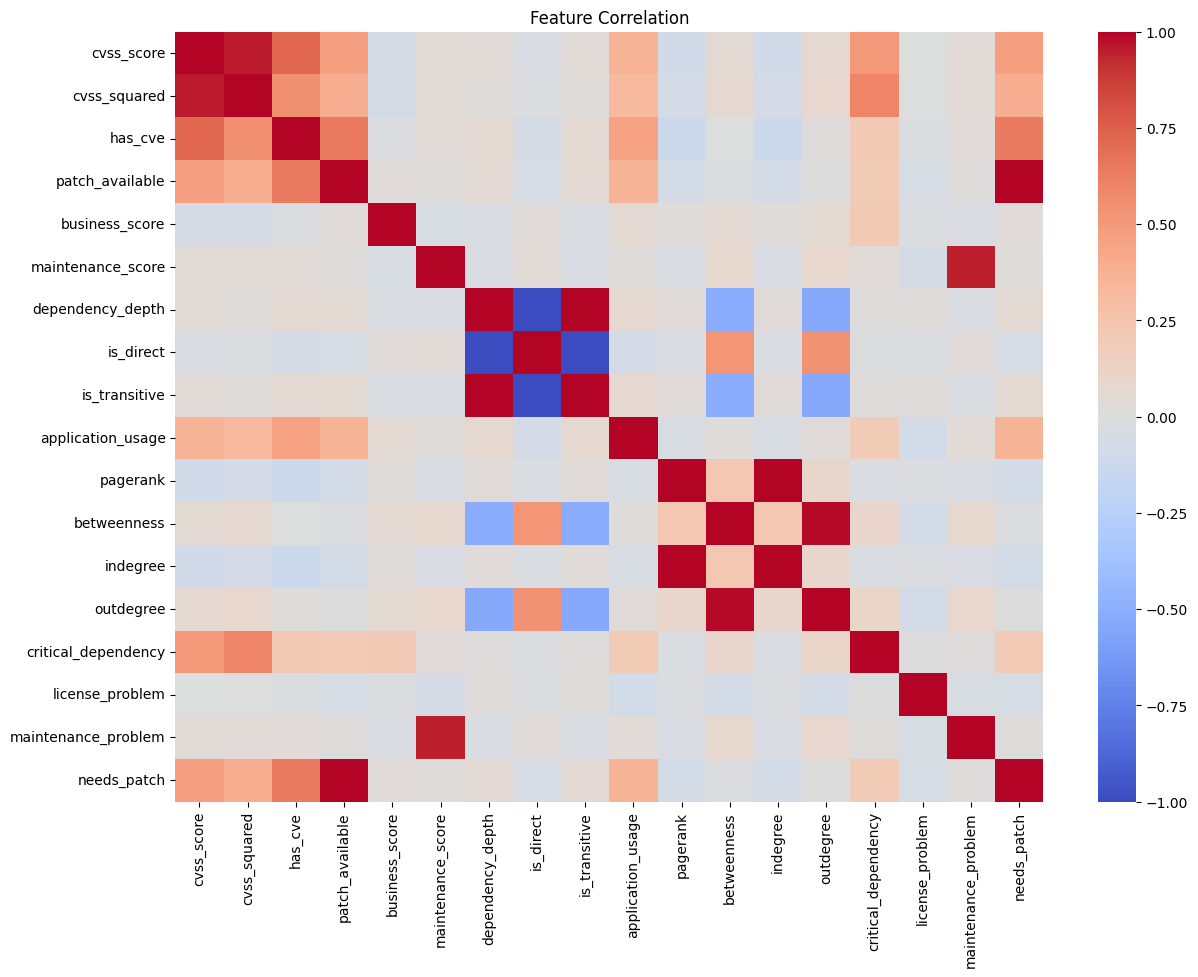

In [42]:
# ==========================================================
# Correlation Matrix
# ==========================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Feature Correlation")

plt.show()

In [43]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20, random_state=42, stratify=y
)

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

Training : (624, 18)
Testing  : (156, 18)


In [ ]:
# ==========================================================
# NOTEBOOK CELL 29
# Train Multiple ML Models
# ==========================================================

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

SEED = 42
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        class_weight="balanced",
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=SEED,
        class_weight="balanced",
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=SEED
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=SEED
    )
}

results = []

best_model = None
best_score = 0

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print("=" * 80)
print("Training Models")
print("=" * 80)

for name, model in models.items():

    print(f"\n{name}")

    cv_score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    ).mean()

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "CV Accuracy": round(cv_score,4),
        "Accuracy": round(accuracy,4),
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1": round(f1,4)
    })

    if accuracy > best_score:
        best_score = accuracy
        best_model = model
        best_name = name

results = pd.DataFrame(results)

display(results.sort_values("Accuracy", ascending=False))

print("\nBest Model :", best_name)
print("Best Accuracy :", round(best_score,4))

Training Models

Random Forest

Extra Trees

Gradient Boosting

CatBoost


,Model,CV Accuracy,Accuracy,Precision,Recall,F1
3,CatBoost,0.7709,0.8141,0.8150,0.8141,0.8128
2,Gradient Boosting,0.7324,0.7885,0.7899,0.7885,0.7865
0,Random Forest,0.7612,0.7756,0.7767,0.7756,0.7735
1,Extra Trees,0.7564,0.7756,0.7758,0.7756,0.7741



Best Model : CatBoost
Best Accuracy : 0.8141


In [45]:
print("\nSaving Best Model to Disk")
path_to_model = MODEL_DIR / f"best_model_{best_name.replace(' ', '_')}.joblib"
joblib.dump(best_model, path_to_model)
print(f"Model saved to {path_to_model}")


Saving Best Model to Disk
Model saved to models/best_model_CatBoost.joblib
